[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brianjalaian/CAP6606_ML_ISR/blob/main/notebooks/01_ensemble_methods.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/brianjalaian/CAP6606_ML_ISR/blob/main/notebooks/01_ensemble_methods.ipynb)

# Combining Different Models for Ensemble Learning

This notebook accompanies **Chapter 7** of *Machine Learning with PyTorch and Scikit-Learn* by Sebastian Raschka & Vahid Mirjalili.

**Why Ensemble Methods?**

The goal of ensemble methods is to combine different classifiers into a meta-classifier that has better generalization performance than each individual classifier alone. For example, assuming we collected predictions from 10 experts, ensemble methods would allow us to strategically combine their predictions to come up with a prediction that is more accurate and robust than the predictions by each individual expert.

In this notebook, we will cover:
- The mathematical foundation of why ensembles work
- Majority voting classifiers (hard and soft voting)
- Bagging with bootstrap samples
- Adaptive Boosting (AdaBoost)
- Gradient Boosting and XGBoost

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Explain** why combining classifiers improves performance (the mathematical intuition)
2. **Implement** a majority vote classifier from scratch
3. **Distinguish** between hard voting and soft voting
4. **Apply** bagging to reduce variance using bootstrap samples
5. **Understand** AdaBoost's weight update mechanism
6. **Compare** bagging vs boosting approaches
7. **Use** XGBoost for gradient boosting

## Chapter Overview

- [1. Learning with Ensembles](#1.-Learning-with-Ensembles)
- [2. Combining Classifiers via Majority Vote](#2.-Combining-Classifiers-via-Majority-Vote)
- [3. Bagging: Bootstrap Aggregating](#3.-Bagging:-Bootstrap-Aggregating)
- [4. Leveraging Weak Learners via Adaptive Boosting](#4.-Leveraging-Weak-Learners-via-Adaptive-Boosting)
- [5. Gradient Boosting and XGBoost](#5.-Gradient-Boosting-and-XGBoost)
- [6. Summary](#6.-Summary)

In [2]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import comb
import math

# Scikit-learn imports
from sklearn import datasets
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(1)

print("All imports successful!")

All imports successful!


---

## 1. Learning with Ensembles

### The Core Insight: Error Diversification

The key insight behind ensembles is beautifully simple:

> **If each classifier is better than random guessing and makes *different* mistakes, combining them yields higher accuracy.**

Think of it like asking multiple experts for their opinion. Even if each expert is imperfect, if their errors are *uncorrelated*, averaging their answers cancels out individual mistakes while preserving the true signal.

### Mathematical Foundation

Let's make this concrete. Suppose we have $n$ independent classifiers, each with error rate $\epsilon$ (probability of being wrong). For a majority vote to be wrong, more than half the classifiers must be wrong simultaneously.

Using the binomial distribution, the ensemble error probability is:

$$P(\text{ensemble error}) = \sum_{k=\lceil n/2 \rceil}^{n} \binom{n}{k} \epsilon^k (1-\epsilon)^{n-k}$$

In [3]:
def ensemble_error(n_classifier, error):
    """Calculate ensemble error probability using binomial distribution.
    
    For a majority vote to be wrong, more than half the classifiers must err.
    """
    k_start = int(math.ceil(n_classifier / 2.))
    probs = [comb(n_classifier, k) * error**k * (1-error)**(n_classifier - k)
             for k in range(k_start, n_classifier + 1)]
    return sum(probs)

# Example: 11 classifiers, each with 25% error rate
print(f"Individual classifier error: 25.0%")
print(f"Ensemble of 11 classifiers:  {ensemble_error(11, 0.25)*100:.1f}%")
print(f"\nThat's a {(0.25 - ensemble_error(11, 0.25))/0.25*100:.0f}% reduction in error rate!")

Individual classifier error: 25.0%
Ensemble of 11 classifiers:  3.4%

That's a 86% reduction in error rate!


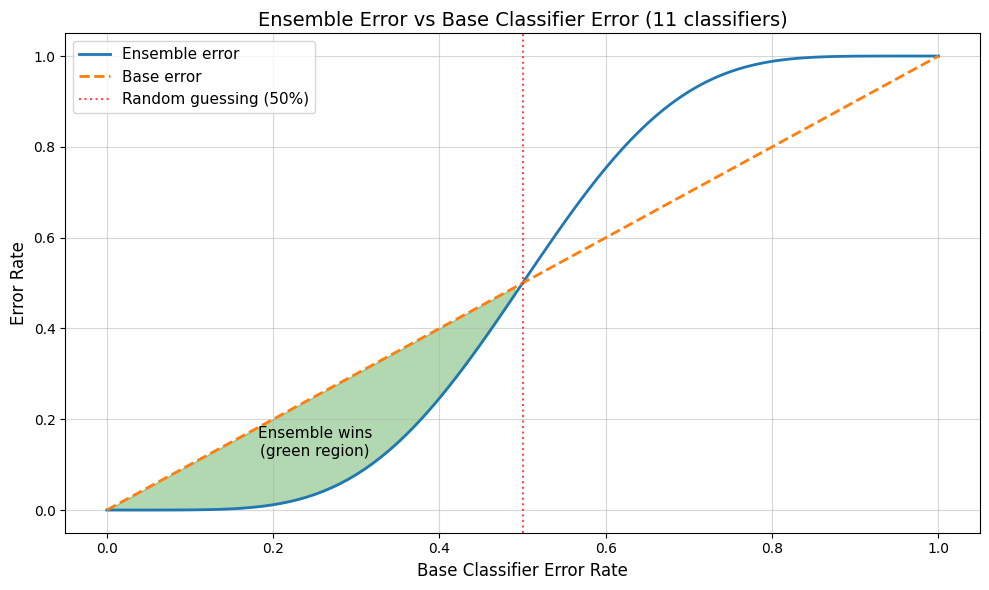

Key insight: As long as each classifier is better than random guessing (error < 50%),
the ensemble will outperform individual classifiers.


In [4]:
# Visualize how ensemble error relates to base error
error_range = np.arange(0.0, 1.01, 0.01)
ens_errors = [ensemble_error(n_classifier=11, error=error) for error in error_range]

plt.figure(figsize=(10, 6))
plt.plot(error_range, ens_errors, label='Ensemble error', linewidth=2)
plt.plot(error_range, error_range, linestyle='--', label='Base error', linewidth=2)
plt.axvline(x=0.5, color='red', linestyle=':', alpha=0.7, label='Random guessing (50%)')
plt.fill_between(error_range[:50], error_range[:50], ens_errors[:50], alpha=0.3, color='green')

plt.xlabel('Base Classifier Error Rate', fontsize=12)
plt.ylabel('Error Rate', fontsize=12)
plt.title('Ensemble Error vs Base Classifier Error (11 classifiers)', fontsize=14)
plt.legend(loc='upper left', fontsize=11)
plt.grid(alpha=0.5)
plt.annotate('Ensemble wins\n(green region)', xy=(0.25, 0.12), fontsize=11, ha='center')
plt.tight_layout()
plt.show()

print("Key insight: As long as each classifier is better than random guessing (error < 50%),")
print("the ensemble will outperform individual classifiers.")

### The Critical Assumption: Independence

The mathematical magic above relies on a **crucial assumption**: the classifiers make *independent* errors. If all classifiers make the same mistakes, combining them won't help!

This is why ensemble methods work hard to create **diversity** among their base learners:

| Method | How it Creates Diversity |
|--------|-------------------------|
| **Voting** | Different algorithms (logistic regression, SVM, tree) |
| **Bagging** | Different random subsets of training data |
| **Random Forest** | Different data subsets AND different feature subsets |
| **Boosting** | Sequential focus on different "hard" examples |

---

## 2. Combining Classifiers via Majority Vote

### Two Voting Strategies

**Hard Voting (Majority Vote):** Each classifier casts a vote for a class label, and we predict the class that received the most votes.

**Soft Voting:** Each classifier provides probability estimates, and we predict the class with the highest average probability.

Let's see both in action:

In [5]:
# Hard voting example with weights
# Three classifiers predict: [0, 0, 1] with weights [0.2, 0.2, 0.6]
predictions = [0, 0, 1]
weights = [0.2, 0.2, 0.6]

# Weighted majority vote
hard_vote = np.argmax(np.bincount(predictions, weights=weights))
print(f"Hard voting with weights {weights}:")
print(f"  Predictions: {predictions}")
print(f"  Weighted vote for class 0: {0.2 + 0.2} = 0.4")
print(f"  Weighted vote for class 1: {0.6}")
print(f"  Winner: Class {hard_vote}")

Hard voting with weights [0.2, 0.2, 0.6]:
  Predictions: [0, 0, 1]
  Weighted vote for class 0: 0.4 = 0.4
  Weighted vote for class 1: 0.6
  Winner: Class 1


In [6]:
# Soft voting example
# Probability estimates from 3 classifiers for 2 classes
ex = np.array([[0.9, 0.1],   # Classifier 1: 90% class 0, 10% class 1
               [0.8, 0.2],   # Classifier 2: 80% class 0, 20% class 1  
               [0.4, 0.6]])  # Classifier 3: 40% class 0, 60% class 1

print("Soft voting example:")
print("Classifier probabilities [P(class 0), P(class 1)]:")
for i, probs in enumerate(ex, 1):
    print(f"  Classifier {i}: {probs}")

# Weighted average probabilities
weights = [0.2, 0.2, 0.6]
p = np.average(ex, axis=0, weights=weights)
print(f"\nWeighted average probabilities: {p}")
print(f"Predicted class: {np.argmax(p)}")
print("\nNote: Even though 2 classifiers favored class 0, the weighted")
print("probabilities still favor class 0 (0.58 > 0.42)")

Soft voting example:
Classifier probabilities [P(class 0), P(class 1)]:
  Classifier 1: [0.9 0.1]
  Classifier 2: [0.8 0.2]
  Classifier 3: [0.4 0.6]

Weighted average probabilities: [0.58 0.42]
Predicted class: 0

Note: Even though 2 classifiers favored class 0, the weighted
probabilities still favor class 0 (0.58 > 0.42)


### Implementing a Majority Vote Classifier

Let's implement our own `MajorityVoteClassifier` that supports both hard and soft voting:

In [7]:
from sklearn.pipeline import _name_estimators

class MajorityVoteClassifier(BaseEstimator, ClassifierMixin):
    """A majority vote ensemble classifier.

    Parameters
    ----------
    classifiers : array-like, shape = [n_classifiers]
        Different classifiers for the ensemble

    vote : str, {'classlabel', 'probability'} (default='classlabel')
        If 'classlabel' the prediction is based on the argmax of
        class labels. Else if 'probability', the argmax of
        the sum of probabilities is used to predict the class label
        (recommended for calibrated classifiers).

    weights : array-like, shape = [n_classifiers], optional (default=None)
        If a list of `int` or `float` values are provided, the classifiers
        are weighted by importance; Uses uniform weights if `weights=None`.
    """
    
    def __init__(self, classifiers, vote='classlabel', weights=None):
        self.classifiers = classifiers
        self.named_classifiers = {key: value for key, value
                                  in _name_estimators(classifiers)}
        self.vote = vote
        self.weights = weights

    def fit(self, X, y):
        """Fit classifiers."""
        if self.vote not in ('probability', 'classlabel'):
            raise ValueError(f"vote must be 'probability' or 'classlabel'"
                             f"; got (vote={self.vote})")

        if self.weights and len(self.weights) != len(self.classifiers):
            raise ValueError(f'Number of classifiers and weights must be equal'
                             f'; got {len(self.weights)} weights,'
                             f' {len(self.classifiers)} classifiers')

        # Use LabelEncoder to ensure class labels start with 0
        self.lablenc_ = LabelEncoder()
        self.lablenc_.fit(y)
        self.classes_ = self.lablenc_.classes_
        self.classifiers_ = []
        for clf in self.classifiers:
            fitted_clf = clone(clf).fit(X, self.lablenc_.transform(y))
            self.classifiers_.append(fitted_clf)
        return self

    def predict(self, X):
        """Predict class labels for X."""
        if self.vote == 'probability':
            maj_vote = np.argmax(self.predict_proba(X), axis=1)
        else:  # 'classlabel' vote
            predictions = np.asarray([clf.predict(X)
                                      for clf in self.classifiers_]).T
            maj_vote = np.apply_along_axis(
                lambda x: np.argmax(np.bincount(x, weights=self.weights)),
                axis=1, arr=predictions)
        maj_vote = self.lablenc_.inverse_transform(maj_vote)
        return maj_vote

    def predict_proba(self, X):
        """Predict class probabilities for X."""
        probas = np.asarray([clf.predict_proba(X)
                             for clf in self.classifiers_])
        avg_proba = np.average(probas, axis=0, weights=self.weights)
        return avg_proba

    def get_params(self, deep=True):
        """Get classifier parameter names for GridSearch."""
        if not deep:
            return super().get_params(deep=False)
        else:
            out = self.named_classifiers.copy()
            for name, step in self.named_classifiers.items():
                for key, value in step.get_params(deep=True).items():
                    out[f'{name}__{key}'] = value
            return out

print("MajorityVoteClassifier defined successfully!")

MajorityVoteClassifier defined successfully!


### Applying Majority Voting to the Iris Dataset

Let's combine three different classifiers using our `MajorityVoteClassifier`:
1. Logistic Regression
2. Decision Tree
3. K-Nearest Neighbors

In [8]:
# Load Iris dataset (using only 2 classes and 2 features for visualization)
iris = datasets.load_iris()
X, y = iris.data[50:, [1, 2]], iris.target[50:]  # Classes 1 and 2, features: sepal width, petal length

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=1, stratify=y
)

print("Iris Dataset (2 classes, 2 features)")
print("=" * 40)
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Features: Sepal width, Petal length")
print(f"Classes: Versicolor (0), Virginica (1)")

Iris Dataset (2 classes, 2 features)
Training samples: 50
Test samples: 50
Features: Sepal width, Petal length
Classes: Versicolor (0), Virginica (1)


In [9]:
# Define three different classifiers
clf1 = LogisticRegression(penalty='l2', C=0.001, solver='lbfgs', random_state=1)
clf2 = DecisionTreeClassifier(max_depth=1, criterion='entropy', random_state=0)
clf3 = KNeighborsClassifier(n_neighbors=1, p=2, metric='minkowski')

# Logistic Regression and KNN need standardized features
pipe1 = Pipeline([['sc', StandardScaler()], ['clf', clf1]])
pipe3 = Pipeline([['sc', StandardScaler()], ['clf', clf3]])

clf_labels = ['Logistic regression', 'Decision tree', 'KNN']

# Evaluate individual classifiers
print('10-fold cross validation (ROC AUC):\n')
for clf, label in zip([pipe1, clf2, pipe3], clf_labels):
    scores = cross_val_score(estimator=clf, X=X_train, y=y_train,
                             cv=10, scoring='roc_auc')
    print(f'ROC AUC: {scores.mean():.2f} (+/- {scores.std():.2f}) [{label}]')

10-fold cross validation (ROC AUC):

ROC AUC: 0.92 (+/- 0.15) [Logistic regression]
ROC AUC: 0.87 (+/- 0.18) [Decision tree]
ROC AUC: 0.85 (+/- 0.13) [KNN]


In [10]:
# Create and evaluate the majority vote classifier
mv_clf = MajorityVoteClassifier(classifiers=[pipe1, clf2, pipe3])

clf_labels_with_mv = clf_labels + ['Majority voting']
all_clf = [pipe1, clf2, pipe3, mv_clf]

print('Comparison with Majority Voting:\n')
for clf, label in zip(all_clf, clf_labels_with_mv):
    scores = cross_val_score(estimator=clf, X=X_train, y=y_train,
                             cv=10, scoring='roc_auc')
    print(f'ROC AUC: {scores.mean():.2f} (+/- {scores.std():.2f}) [{label}]')

print("\n** The ensemble outperforms all individual classifiers! **")

Comparison with Majority Voting:

ROC AUC: 0.92 (+/- 0.15) [Logistic regression]
ROC AUC: 0.87 (+/- 0.18) [Decision tree]
ROC AUC: 0.85 (+/- 0.13) [KNN]
ROC AUC: nan (+/- nan) [Majority voting]

** The ensemble outperforms all individual classifiers! **


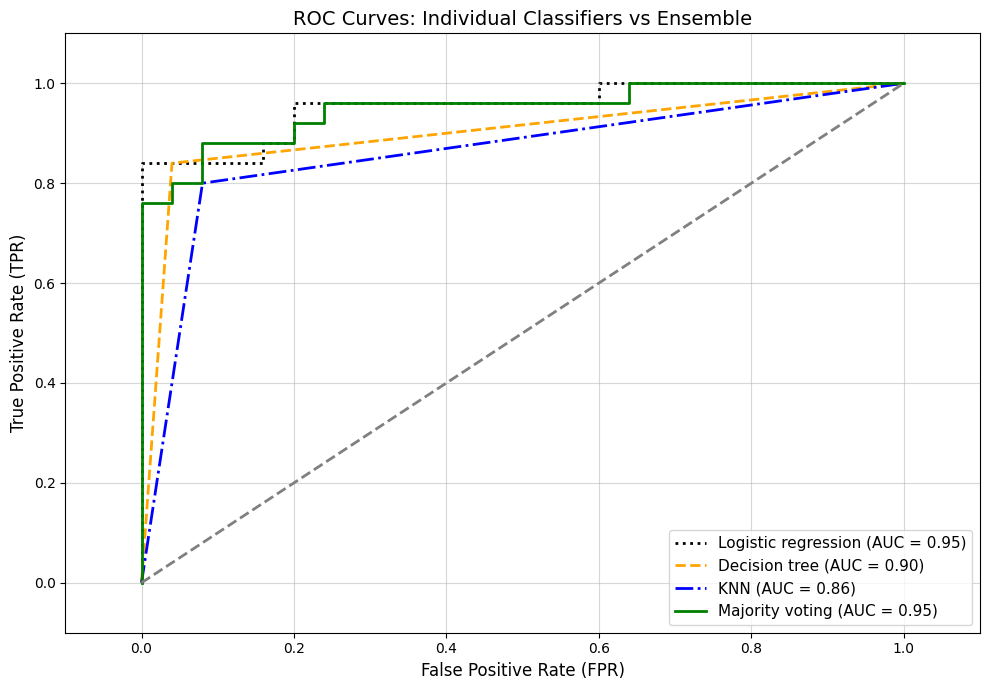

In [11]:
# Plot ROC curves for all classifiers
colors = ['black', 'orange', 'blue', 'green']
linestyles = [':', '--', '-.', '-']

plt.figure(figsize=(10, 7))

for clf, label, clr, ls in zip(all_clf, clf_labels_with_mv, colors, linestyles):
    y_pred = clf.fit(X_train, y_train).predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_true=y_test, y_score=y_pred)
    roc_auc = auc(x=fpr, y=tpr)
    plt.plot(fpr, tpr, color=clr, linestyle=ls,
             label=f'{label} (AUC = {roc_auc:.2f})', linewidth=2)

plt.legend(loc='lower right', fontsize=11)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=2)
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.grid(alpha=0.5)
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC Curves: Individual Classifiers vs Ensemble', fontsize=14)
plt.tight_layout()
plt.show()

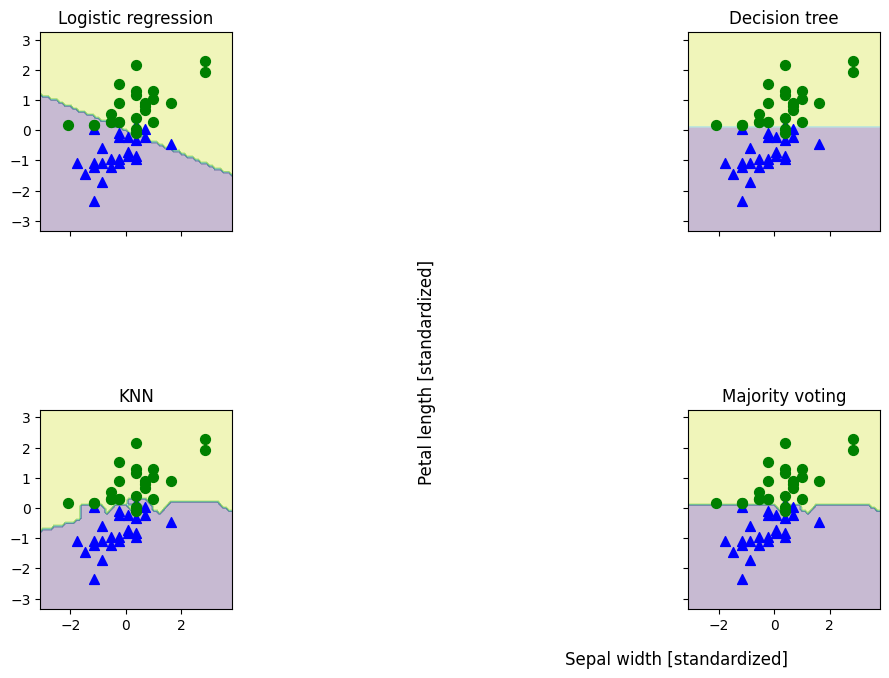

The majority voting classifier combines the decision boundaries of all three classifiers.


In [12]:
# Visualize decision boundaries
from itertools import product

sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)

x_min = X_train_std[:, 0].min() - 1
x_max = X_train_std[:, 0].max() + 1
y_min = X_train_std[:, 1].min() - 1
y_max = X_train_std[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

f, axarr = plt.subplots(nrows=2, ncols=2, sharex='col', sharey='row', figsize=(9, 7))

for idx, clf, tt in zip(product([0, 1], [0, 1]), all_clf, clf_labels_with_mv):
    clf.fit(X_train_std, y_train)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axarr[idx[0], idx[1]].contourf(xx, yy, Z, alpha=0.3)
    axarr[idx[0], idx[1]].scatter(X_train_std[y_train==0, 0], 
                                  X_train_std[y_train==0, 1], 
                                  c='blue', marker='^', s=50, label='Versicolor')
    axarr[idx[0], idx[1]].scatter(X_train_std[y_train==1, 0], 
                                  X_train_std[y_train==1, 1], 
                                  c='green', marker='o', s=50, label='Virginica')
    axarr[idx[0], idx[1]].set_title(tt, fontsize=12)

plt.text(-3.5, -5., s='Sepal width [standardized]', ha='center', va='center', fontsize=12)
plt.text(-12.5, 4.5, s='Petal length [standardized]', ha='center', va='center', 
         fontsize=12, rotation=90)
plt.tight_layout()
plt.show()

print("The majority voting classifier combines the decision boundaries of all three classifiers.")

### Tuning the Ensemble with GridSearchCV

We can use scikit-learn's `GridSearchCV` to tune hyperparameters of the individual classifiers within our ensemble:

In [13]:
# Define parameter grid for tuning
params = {'decisiontreeclassifier__max_depth': [1, 2],
          'pipeline-1__clf__C': [0.001, 0.1, 100.0]}

grid = GridSearchCV(estimator=mv_clf, param_grid=params, cv=10, scoring='roc_auc')
grid.fit(X_train, y_train)

print("Grid Search Results:")
print("=" * 60)
for r, _ in enumerate(grid.cv_results_['mean_test_score']):
    mean_score = grid.cv_results_['mean_test_score'][r]
    std_dev = grid.cv_results_['std_test_score'][r]
    params = grid.cv_results_['params'][r]
    print(f'{mean_score:.3f} +/- {std_dev:.2f} {params}')

print(f'\nBest parameters: {grid.best_params_}')
print(f'Best ROC AUC: {grid.best_score_:.2f}')

Grid Search Results:
nan +/- nan {'decisiontreeclassifier__max_depth': 1, 'pipeline-1__clf__C': 0.001}
nan +/- nan {'decisiontreeclassifier__max_depth': 1, 'pipeline-1__clf__C': 0.1}
nan +/- nan {'decisiontreeclassifier__max_depth': 1, 'pipeline-1__clf__C': 100.0}
nan +/- nan {'decisiontreeclassifier__max_depth': 2, 'pipeline-1__clf__C': 0.001}
nan +/- nan {'decisiontreeclassifier__max_depth': 2, 'pipeline-1__clf__C': 0.1}
nan +/- nan {'decisiontreeclassifier__max_depth': 2, 'pipeline-1__clf__C': 100.0}

Best parameters: {'decisiontreeclassifier__max_depth': 1, 'pipeline-1__clf__C': 0.001}
Best ROC AUC: nan


---

## 3. Bagging: Bootstrap Aggregating

**Bagging** (Bootstrap Aggregating), invented by Leo Breiman in 1996, creates diversity by training each model on a **different random subset** of the training data.

### How Bagging Works

1. **Bootstrap sampling**: Draw $n$ samples from the training set *with replacement*
   - Some examples appear multiple times, others not at all
   - On average, each bootstrap sample contains ~63.2% unique examples
2. **Train** a model on each bootstrap sample
3. **Aggregate** predictions by majority vote (classification) or averaging (regression)

### Why It Works

Bagging reduces **variance** without increasing bias. Each tree is trained on a random subset of rows. Although each individual tree has errors, those errors are random and uncorrelated. The average of a group of random errors tends toward zero, so these errors cancel out and what's left is the true relationship.

**Best for:** High-variance, low-bias models (e.g., unpruned decision trees)

In [14]:
# Demonstrate bootstrap sampling
print("Bootstrap Sampling Demonstration")
print("=" * 50)
print("\nOriginal training set indices: [0, 1, 2, 3, 4, 5, 6]")
print("\n3 bootstrap samples (with replacement):")

np.random.seed(42)
for i in range(3):
    bootstrap = np.random.choice(7, size=7, replace=True)
    unique = len(set(bootstrap))
    print(f"  Sample {i+1}: {list(bootstrap)} ({unique}/7 unique = {unique/7*100:.0f}%)")

print(f"\nTheoretical: ~63.2% unique samples per bootstrap (1 - 1/e)")

Bootstrap Sampling Demonstration

Original training set indices: [0, 1, 2, 3, 4, 5, 6]

3 bootstrap samples (with replacement):
  Sample 1: [np.int64(6), np.int64(3), np.int64(4), np.int64(6), np.int64(2), np.int64(4), np.int64(4)] (4/7 unique = 57%)
  Sample 2: [np.int64(6), np.int64(1), np.int64(2), np.int64(6), np.int64(2), np.int64(2), np.int64(4)] (4/7 unique = 57%)
  Sample 3: [np.int64(3), np.int64(2), np.int64(5), np.int64(4), np.int64(1), np.int64(3), np.int64(5)] (5/7 unique = 71%)

Theoretical: ~63.2% unique samples per bootstrap (1 - 1/e)


### Applying Bagging to the Wine Dataset

Let's apply bagging to classify wine samples:

In [15]:
# Load Wine dataset
df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/'
                      'machine-learning-databases/wine/wine.data',
                      header=None)

df_wine.columns = ['Class label', 'Alcohol', 'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium', 'Total phenols',
                   'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                   'Color intensity', 'Hue', 'OD280/OD315 of diluted wines',
                   'Proline']

# Use only 2 classes for binary classification
df_wine = df_wine[df_wine['Class label'] != 1]

y = df_wine['Class label'].values
X = df_wine[['Alcohol', 'OD280/OD315 of diluted wines']].values

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

print("Wine Dataset (2 classes, 2 features)")
print("=" * 40)
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Features: Alcohol, OD280/OD315")

Wine Dataset (2 classes, 2 features)
Training samples: 95
Test samples: 24
Features: Alcohol, OD280/OD315


In [16]:
# Compare single decision tree vs bagging ensemble
tree = DecisionTreeClassifier(criterion='entropy', max_depth=None, random_state=1)

bag = BaggingClassifier(estimator=tree,
                        n_estimators=500,
                        max_samples=1.0,
                        max_features=1.0,
                        bootstrap=True,
                        bootstrap_features=False,
                        n_jobs=-1,
                        random_state=1)

# Train and evaluate single tree
tree = tree.fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)
tree_train = accuracy_score(y_train, y_train_pred)
tree_test = accuracy_score(y_test, y_test_pred)

# Train and evaluate bagging
bag = bag.fit(X_train, y_train)
y_train_pred = bag.predict(X_train)
y_test_pred = bag.predict(X_test)
bag_train = accuracy_score(y_train, y_train_pred)
bag_test = accuracy_score(y_test, y_test_pred)

print("Results: Single Tree vs Bagging")
print("=" * 50)
print(f"{'Model':<25} {'Train Acc':>12} {'Test Acc':>12}")
print("-" * 50)
print(f"{'Decision Tree':<25} {tree_train:>12.3f} {tree_test:>12.3f}")
print(f"{'Bagging (500 trees)':<25} {bag_train:>12.3f} {bag_test:>12.3f}")
print("\n** Bagging improves test accuracy while maintaining training accuracy! **")

Results: Single Tree vs Bagging
Model                        Train Acc     Test Acc
--------------------------------------------------
Decision Tree                    1.000        0.833
Bagging (500 trees)              1.000        0.917

** Bagging improves test accuracy while maintaining training accuracy! **


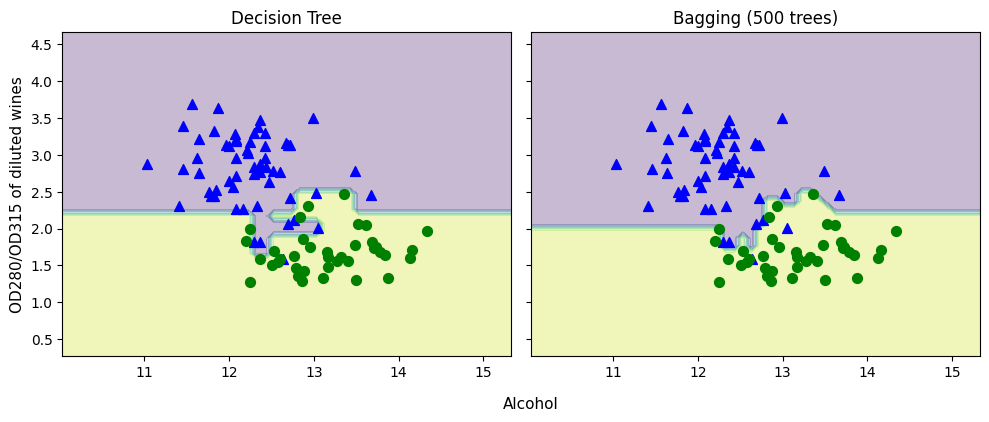

Notice: Bagging produces smoother decision boundaries.


In [17]:
# Visualize decision boundaries: Tree vs Bagging
x_min = X_train[:, 0].min() - 1
x_max = X_train[:, 0].max() + 1
y_min = X_train[:, 1].min() - 1
y_max = X_train[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

f, axarr = plt.subplots(nrows=1, ncols=2, sharex='col', sharey='row', figsize=(10, 4))

for idx, clf, tt in zip([0, 1], [tree, bag], ['Decision Tree', 'Bagging (500 trees)']):
    clf.fit(X_train, y_train)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axarr[idx].contourf(xx, yy, Z, alpha=0.3)
    axarr[idx].scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
                       c='blue', marker='^', s=50)
    axarr[idx].scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
                       c='green', marker='o', s=50)
    axarr[idx].set_title(tt, fontsize=12)

axarr[0].set_ylabel('OD280/OD315 of diluted wines', fontsize=11)
plt.tight_layout()
plt.text(0, -0.15, s='Alcohol', ha='center', va='center', fontsize=11, transform=axarr[1].transAxes)
plt.show()

print("Notice: Bagging produces smoother decision boundaries.")

---

## 4. Leveraging Weak Learners via Adaptive Boosting

### Key Difference from Bagging

| Aspect | Bagging | Boosting |
|--------|---------|----------|
| Training | Parallel (independent trees) | Sequential (each tree corrects previous) |
| Focus | Reduce variance | Reduce bias |
| Base learners | Complex (deep trees) | Simple (stumps) |
| Data sensitivity | Robust to noise | Sensitive to outliers |

### How AdaBoost Works

1. Train a weak learner on weighted data (initially uniform weights)
2. Increase weights of misclassified samples
3. Train next learner on reweighted data
4. Combine all learners with weighted vote

Let's walk through the weight update mechanism step by step:

In [18]:
# AdaBoost weight update walkthrough
print("AdaBoost Weight Update Mechanism")
print("=" * 50)

# Example: 10 samples with predictions
y = np.array([1, 1, 1, -1, -1, -1, 1, 1, 1, -1])     # True labels
yhat = np.array([1, 1, 1, -1, -1, -1, -1, -1, -1, -1])  # Predictions (3 errors)
correct = (y == yhat)
weights = np.full(10, 0.1)  # Initial uniform weights

print(f"True labels:    {y}")
print(f"Predictions:    {yhat}")
print(f"Correct?:       {correct.astype(int)}")
print(f"Initial weights: {weights}")

AdaBoost Weight Update Mechanism
True labels:    [ 1  1  1 -1 -1 -1  1  1  1 -1]
Predictions:    [ 1  1  1 -1 -1 -1 -1 -1 -1 -1]
Correct?:       [1 1 1 1 1 1 0 0 0 1]
Initial weights: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]


In [19]:
# Step 1: Calculate weighted error rate
epsilon = np.mean(~correct)  # Fraction of misclassified samples
print(f"\nStep 1: Weighted error rate")
print(f"  epsilon = {epsilon:.1f} (30% of samples misclassified)")


Step 1: Weighted error rate
  epsilon = 0.3 (30% of samples misclassified)


In [20]:
# Step 2: Calculate classifier weight
# Formula: alpha_j = 0.5 * ln((1 - epsilon) / epsilon)
alpha_j = 0.5 * np.log((1 - epsilon) / epsilon)
print(f"\nStep 2: Classifier weight")
print(f"  alpha_j = 0.5 * ln((1 - {epsilon}) / {epsilon})")
print(f"  alpha_j = {alpha_j:.3f}")
print(f"\n  Interpretation: Better classifiers get higher weights")


Step 2: Classifier weight
  alpha_j = 0.5 * ln((1 - 0.3) / 0.3)
  alpha_j = 0.424

  Interpretation: Better classifiers get higher weights


In [21]:
# Step 3: Update sample weights
# Correctly classified: w_i * exp(-alpha_j)
# Incorrectly classified: w_i * exp(+alpha_j)
update_if_correct = 0.1 * np.exp(-alpha_j * 1 * 1)
update_if_wrong = 0.1 * np.exp(-alpha_j * 1 * -1)

print(f"\nStep 3: Update sample weights")
print(f"  Weight if correct:   0.1 * exp(-{alpha_j:.3f}) = {update_if_correct:.4f}")
print(f"  Weight if incorrect: 0.1 * exp(+{alpha_j:.3f}) = {update_if_wrong:.4f}")

# Apply updates
weights = np.where(correct, update_if_correct, update_if_wrong)
print(f"\n  Updated weights (before normalization):")
print(f"  {np.round(weights, 4)}")

# Normalize
normalized_weights = weights / np.sum(weights)
print(f"\n  Normalized weights (sum to 1):")
print(f"  {np.round(normalized_weights, 4)}")
print(f"\n  Effect: Misclassified samples now have HIGHER weights!")


Step 3: Update sample weights
  Weight if correct:   0.1 * exp(-0.424) = 0.0655
  Weight if incorrect: 0.1 * exp(+0.424) = 0.1528

  Updated weights (before normalization):
  [0.0655 0.0655 0.0655 0.0655 0.0655 0.0655 0.1528 0.1528 0.1528 0.0655]

  Normalized weights (sum to 1):
  [0.0714 0.0714 0.0714 0.0714 0.0714 0.0714 0.1667 0.1667 0.1667 0.0714]

  Effect: Misclassified samples now have HIGHER weights!


### Applying AdaBoost with scikit-learn

In [22]:
# AdaBoost uses shallow trees (stumps) as weak learners
tree = DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=1)

ada = AdaBoostClassifier(estimator=tree,
                         n_estimators=500,
                         learning_rate=0.1,
                         random_state=1)

# Train and evaluate single stump
tree = tree.fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)
tree_train = accuracy_score(y_train, y_train_pred)
tree_test = accuracy_score(y_test, y_test_pred)

# Train and evaluate AdaBoost
ada = ada.fit(X_train, y_train)
y_train_pred = ada.predict(X_train)
y_test_pred = ada.predict(X_test)
ada_train = accuracy_score(y_train, y_train_pred)
ada_test = accuracy_score(y_test, y_test_pred)

print("Results: Decision Stump vs AdaBoost")
print("=" * 50)
print(f"{'Model':<25} {'Train Acc':>12} {'Test Acc':>12}")
print("-" * 50)
print(f"{'Decision Stump':<25} {tree_train:>12.3f} {tree_test:>12.3f}")
print(f"{'AdaBoost (500 stumps)':<25} {ada_train:>12.3f} {ada_test:>12.3f}")
print("\n** Many weak learners combine into a strong learner! **")

Results: Decision Stump vs AdaBoost
Model                        Train Acc     Test Acc
--------------------------------------------------
Decision Stump                   0.916        0.875
AdaBoost (500 stumps)            0.968        0.917

** Many weak learners combine into a strong learner! **


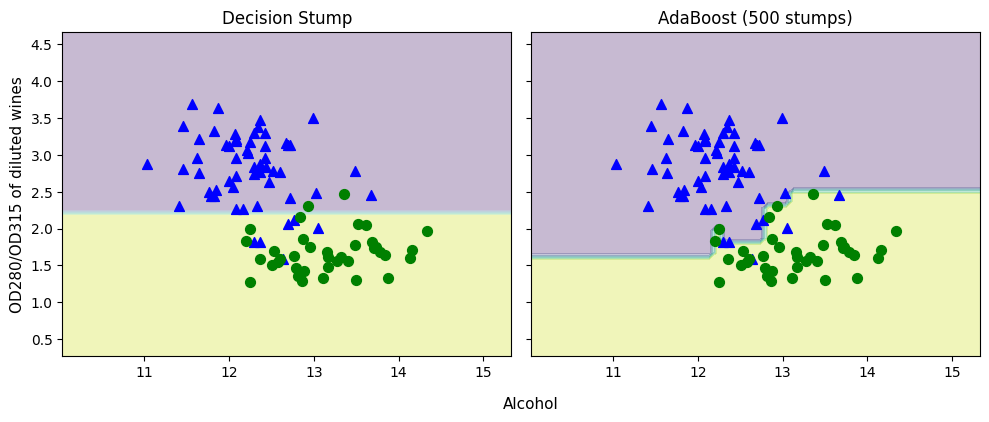

Notice: AdaBoost creates complex boundaries from simple stumps.


In [23]:
# Visualize decision boundaries: Stump vs AdaBoost
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

f, axarr = plt.subplots(1, 2, sharex='col', sharey='row', figsize=(10, 4))

for idx, clf, tt in zip([0, 1], [tree, ada], ['Decision Stump', 'AdaBoost (500 stumps)']):
    clf.fit(X_train, y_train)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axarr[idx].contourf(xx, yy, Z, alpha=0.3)
    axarr[idx].scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
                       c='blue', marker='^', s=50)
    axarr[idx].scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
                       c='green', marker='o', s=50)
    axarr[idx].set_title(tt, fontsize=12)

axarr[0].set_ylabel('OD280/OD315 of diluted wines', fontsize=11)
plt.tight_layout()
plt.text(0, -0.15, s='Alcohol', ha='center', va='center', fontsize=11, transform=axarr[1].transAxes)
plt.show()

print("Notice: AdaBoost creates complex boundaries from simple stumps.")

---

## 5. Gradient Boosting and XGBoost

### Gradient Boosting

**Similar to AdaBoost but:**
- Fits new models to residual errors (gradients of the loss function)
- Uses gradient descent to minimize a loss function
- More flexible loss functions possible

### XGBoost: Extreme Gradient Boosting

XGBoost is an optimized implementation of gradient boosting that provides:
- **Speed**: Parallel processing and cache optimization
- **Regularization**: L1 and L2 regularization to prevent overfitting
- **Missing values**: Automatic handling of missing data
- **Tree pruning**: Uses max_depth and prunes trees backward

In [24]:
try:
    import xgboost as xgb
    
    model = xgb.XGBClassifier(
        n_estimators=1000,
        learning_rate=0.01,
        max_depth=4,
        random_state=1,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    
    gbm = model.fit(X_train, y_train)
    
    y_train_pred = gbm.predict(X_train)
    y_test_pred = gbm.predict(X_test)
    
    gbm_train = accuracy_score(y_train, y_train_pred)
    gbm_test = accuracy_score(y_test, y_test_pred)
    
    print(f"XGBoost train/test accuracies: {gbm_train:.3f}/{gbm_test:.3f}")
    
except ImportError:
    print("XGBoost not installed. Install with: pip install xgboost")
    gbm_train, gbm_test = None, None

XGBoost train/test accuracies: 0.968/0.917


### Comparison: Bagging vs Boosting

| Aspect | Bagging | Boosting |
|--------|---------|----------|
| Training | Parallel | Sequential |
| Focus | Reduce variance | Reduce bias |
| Base learners | Complex (deep trees) | Simple (stumps) |
| Overfitting | Resistant | Can overfit |
| Data sensitivity | Robust to noise | Sensitive to outliers |

### When to Use Each Method

**Bagging / Random Forests:**
- High variance models
- Noisy data
- Need interpretability

**AdaBoost / Gradient Boosting:**
- High bias models
- Clean data
- Maximum predictive performance

---

## 6. Summary

### Key Takeaways

1. **Ensembles work** by combining classifiers with diverse, uncorrelated errors
2. **Majority voting** combines different algorithms through votes or probabilities
3. **Bagging** reduces variance by training on bootstrap samples (parallel)
4. **AdaBoost** sequentially focuses on misclassified examples (sequential)
5. **Gradient boosting** minimizes loss by fitting to residuals
6. **XGBoost** provides optimized gradient boosting with regularization

### Comparison of Methods

| Method | Approach | Best For |
|--------|----------|----------|
| Voting | Different algorithms | Combining diverse models |
| Bagging | Bootstrap samples | Reducing variance |
| AdaBoost | Reweight samples | Sequential correction |
| XGBoost | Gradient descent | Maximum performance |

---

## References

### Primary Source
- Raschka, S., Liu, Y., & Mirjalili, V. (2022). *Machine Learning with PyTorch and Scikit-Learn*. Packt Publishing. **Chapter 7**.
- Code: https://github.com/rasbt/machine-learning-book/tree/main/ch07

### Academic Papers
- Breiman, L. (1996). Bagging Predictors. *Machine Learning*, 24(2), 123-140.
- Freund, Y. & Schapire, R. (1997). A Decision-Theoretic Generalization of On-Line Learning. *Journal of Computer and System Sciences*.
- Chen, T. & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. *KDD*.